<a href="https://colab.research.google.com/github/Emmanuel-NS/Formative1Group7/blob/main/notebooks/pharma_time_series_eda_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative 1 — Task 1: Pharmaceutical Time-Series EDA & Modeling

**Group:** Formative1_GRP7  
**Dataset:** [Pharma Sales Data](https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data) (Milan Zdravković)  
**Problem:** Forecast daily demand (units sold) for pharmaceutical products classified by ATC categories (2014–2019).

---

## Notebook Overview
| Section | Task | Deliverable |
|---------|------|-------------|
| 1–2 | Setup & data load | Clean daily time-series dataframe |
| 3 | Task 1A | EDA — time range, frequency, missing values, distributions |
| 4 | Task 1B | 5+ analytical questions with visualizations (lags & moving averages) |
| 5 | Task 1C | 2+ model experiments with hyperparameter tuning |
| 6 | Export | `pharma_demand_model.pkl` + preprocessing artifacts |

> **Run all cells top-to-bottom.** The dataset auto-downloads in Section 1.1 (one-time Kaggle login — no file upload).

## 1. Environment Setup

In [ ]:
!pip install -q opendatasets pandas numpy matplotlib seaborn scikit-learn xgboost joblib

In [ ]:
import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TARGET_COL = 'N02BE'  # Anilides (Paracetamol) — highest-volume category
ATC_COLUMNS = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

### 1.1 Auto-Download Dataset

Run the cell below — it downloads the data **automatically**. The first time only, it will ask you to type:
- Your **Kaggle username**
- Your **Kaggle API key** (get it free at [kaggle.com/settings](https://www.kaggle.com/settings) → **Create New Token**)

No `kaggle.json` upload needed. If you already downloaded the data in this session, it skips the download.

> **Why not 100% silent?** Kaggle requires a free account login to download datasets — Colab cannot bypass that.

In [ ]:
# Auto-download dataset (no file upload — type username + API key when prompted)
import shutil
import opendatasets as od

KAGGLE_URL = 'https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data'
DATA_FILE = DATA_DIR / 'salesdaily.csv'

if DATA_FILE.exists():
    print(f'Already downloaded: {DATA_FILE}')
else:
    print('Downloading from Kaggle (one-time login)...')
    print('→ When prompted, enter your Kaggle username and API key from kaggle.com/settings')
    od.download(KAGGLE_URL, data_dir=str(DATA_DIR))

    # opendatasets saves to a subfolder — move CSV to data/salesdaily.csv
    for csv in DATA_DIR.rglob('salesdaily.csv'):
        if csv != DATA_FILE:
            shutil.move(str(csv), str(DATA_FILE))
            break

assert DATA_FILE.exists(), 'Download failed — check your Kaggle username and API key.'
print('Ready:', DATA_FILE)
print('Files in data/:', [p.name for p in DATA_DIR.iterdir()])

→ When prompted, enter your Kaggle username and API key from kaggle.com/settings
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: emmanuelnsabagasani
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data


100%|██████████| 352k/352k [00:00<00:00, 52.4MB/s]


Ready: data/salesdaily.csv
Files in data/: ['pharma-sales-data', 'salesdaily.csv']


## 2. Load & Initial Inspection

In [ ]:
# Daily aggregated sales (one row per day, columns = ATC categories)
df_raw = pd.read_csv(DATA_DIR / 'salesdaily.csv')

print('Shape:', df_raw.shape)
print('\nColumns:', df_raw.columns.tolist())
df_raw.head()

Shape: (2106, 13)

Columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [ ]:
# Standardize date column name
date_col = df_raw.columns[0]
df = df_raw.rename(columns={date_col: 'Date'}).copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Total daily demand across all categories (secondary target / feature)
df['Total_Demand'] = df[ATC_COLUMNS].sum(axis=1)

df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          2106 non-null   datetime64[ns]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   object        
 13  Total_Demand  2106 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(3), object(1)
memory usage: 230.5+ KB


,count,mean,min,25%,50%,75%,max,std
Date,2106,2016-11-19 12:00:00.000000256,2014-01-02 00:00:00,2015-06-12 06:00:00,2016-11-19 12:00:00,2018-04-29 18:00:00,2019-10-08 00:00:00,NaN
M01AB,2106.0,5.033683,0.0,3.0,4.99,6.67,17.34,2.737579
M01AE,2106.0,3.89583,0.0,2.34,3.67,5.138,14.463,2.133337
N02BA,2106.0,3.880441,0.0,2.0,3.5,5.2,16.0,2.38401
N02BE,2106.0,29.917095,0.0,19.0,26.9,38.3,161.0,15.590966
N05B,2106.0,8.853627,0.0,5.0,8.0,12.0,54.833333,5.605605
N05C,2106.0,0.593522,0.0,0.0,0.0,1.0,9.0,1.092988
R03,2106.0,5.512262,0.0,1.0,4.0,8.0,45.0,6.428736
R06,2106.0,2.900198,0.0,1.0,2.0,4.0,15.0,2.415816
Year,2106.0,2016.401235,2014.0,2015.0,2016.0,2018.0,2019.0,1.66506


---
## 3. Task 1A — Exploratory Data Analysis

### 3.1 Time Range & Frequency

In [ ]:
start_date = df['Date'].min()
end_date = df['Date'].max()
duration_days = (end_date - start_date).days

# Infer frequency from median gap between consecutive timestamps
median_gap = df['Date'].diff().median()

print('=' * 60)
print('TIME SERIES SUMMARY')
print('=' * 60)
print(f'Time range     : {start_date.date()} → {end_date.date()}')
print(f'Duration       : {duration_days:,} days (~{duration_days/365:.1f} years)')
print(f'Observations   : {len(df):,} rows')
print(f'Median gap     : {median_gap}')
print(f'Granularity    : Daily (1 observation per calendar day)')
print(f'Target variable: {TARGET_COL} (daily units sold)')

TIME SERIES SUMMARY
Time range     : 2014-01-02 → 2019-10-08
Duration       : 2,105 days (~5.8 years)
Observations   : 2,106 rows
Median gap     : 1 days 00:00:00
Granularity    : Daily (1 observation per calendar day)
Target variable: N02BE (daily units sold)


### 3.2 Missing Values — Detection & Handling

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report[missing_report['Missing Count'] > 0]

,Missing Count,Missing %


In [ ]:
# Check for implicit missingness: duplicate dates or large gaps
duplicate_dates = df['Date'].duplicated().sum()
expected_days = pd.date_range(start_date, end_date, freq='D')
missing_dates = expected_days.difference(df['Date'])

print(f'Duplicate dates : {duplicate_dates}')
print(f'Missing calendar days in range: {len(missing_dates)}')
if len(missing_dates) > 0:
    print(f'  First 5 missing: {missing_dates[:5].tolist()}')

Duplicate dates : 0
Missing calendar days in range: 0


In [ ]:
# Handling strategy:
# 1. Reindex to complete daily calendar (captures gaps explicitly)
# 2. Linear interpolation for numeric columns (preserves trend between known points)
# 3. Forward-fill any remaining edge NaNs

df_clean = (
    df.set_index('Date')
      .reindex(expected_days)
      .interpolate(method='time')
      .ffill()
      .reset_index()
      .rename(columns={'index': 'Date'})
)

print('Rows before reindex:', len(df))
print('Rows after reindex :', len(df_clean))
print('Remaining NaNs     :', df_clean.isnull().sum().sum())

df = df_clean.copy()
df['Total_Demand'] = df[ATC_COLUMNS].sum(axis=1)

Rows before reindex: 2106
Rows after reindex : 2106
Remaining NaNs     : 0


**Why this approach?**  
Pharmaceutical POS data can have days with no transactions recorded (store closed, system downtime). Reindexing to a complete daily calendar makes the time index regular — required for lag features and rolling windows. **Time-based linear interpolation** respects chronological order and avoids distorting trends the way row-wise mean imputation would. Forward-fill handles any edge cases at the series start/end.

### 3.3 Statistical Distribution of Numerical Columns

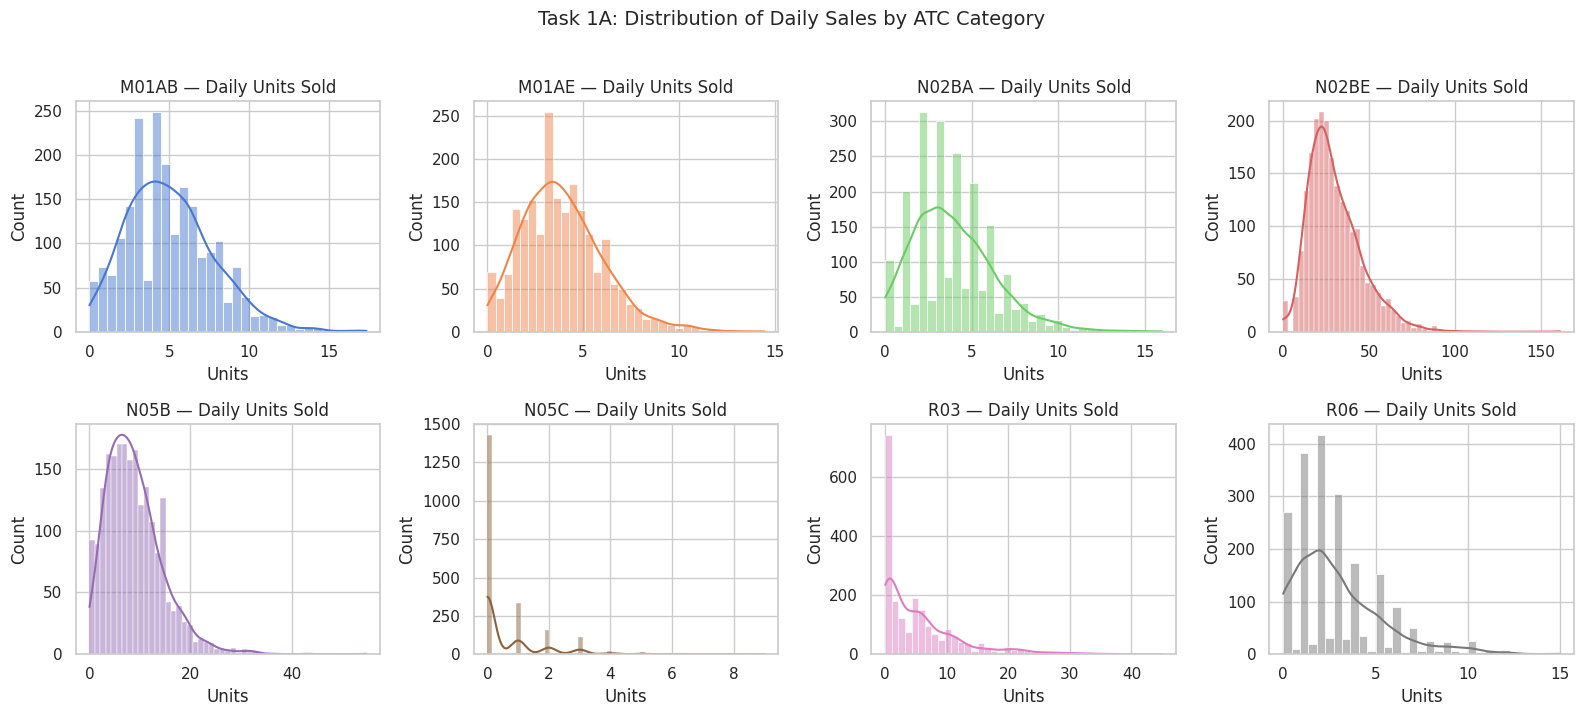

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Total_Demand
count,2106.00,2106.00,2106.00,2106.00,2106.00,2106.00,2106.00,2106.00,2106.00
mean,5.03,3.90,3.88,29.92,8.85,0.59,5.51,2.90,60.59
std,2.74,2.13,2.38,15.59,5.61,1.09,6.43,2.42,21.56
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3.00,2.34,2.00,19.00,5.00,0.00,1.00,1.00,46.45
50%,4.99,3.67,3.50,26.90,8.00,0.00,4.00,2.00,58.47
75%,6.67,5.14,5.20,38.30,12.00,1.00,8.00,4.00,72.81
max,17.34,14.46,16.00,161.00,54.83,9.00,45.00,15.00,198.95


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(ATC_COLUMNS):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette()[i])
    axes[i].set_title(f'{col} — Daily Units Sold')
    axes[i].set_xlabel('Units')

plt.suptitle('Task 1A: Distribution of Daily Sales by ATC Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1A_distributions.png', bbox_inches='tight')
plt.show()

df[ATC_COLUMNS + ['Total_Demand']].describe().round(2)

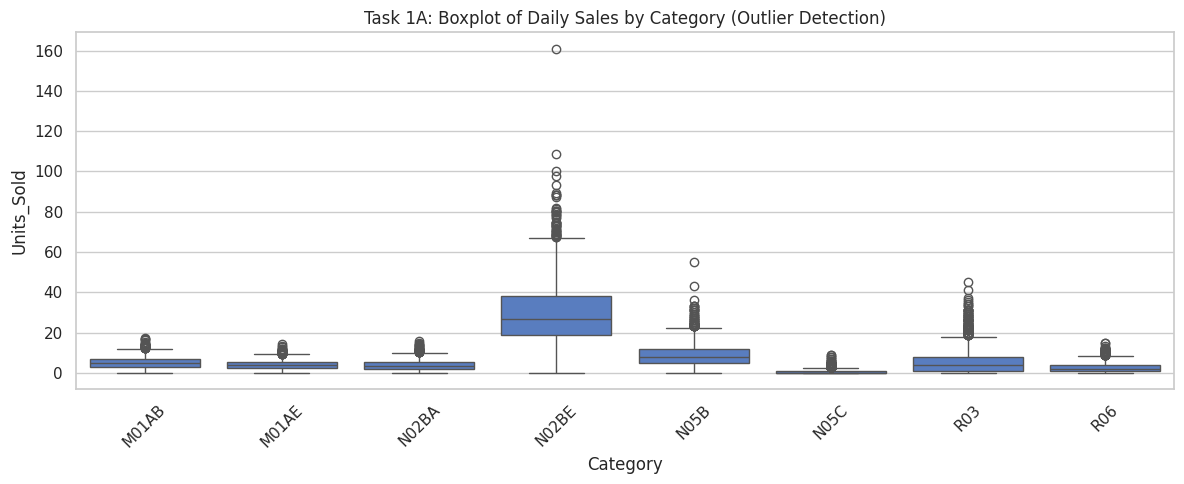

In [ ]:
# Boxplot to highlight outliers / skewness
melted = df.melt(id_vars='Date', value_vars=ATC_COLUMNS, var_name='Category', value_name='Units_Sold')

plt.figure(figsize=(12, 5))
sns.boxplot(data=melted, x='Category', y='Units_Sold')
plt.title('Task 1A: Boxplot of Daily Sales by Category (Outlier Detection)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1A_boxplot.png', bbox_inches='tight')
plt.show()

---
## 4. Task 1B — Analytical Questions

Each question includes **≥1 visualization** and an interpretation cell below it.

### Q1 — Long-Term Trend
**Question:** Is there an increasing or decreasing long-term trend in N02BE (Paracetamol) demand over 2014–2019?

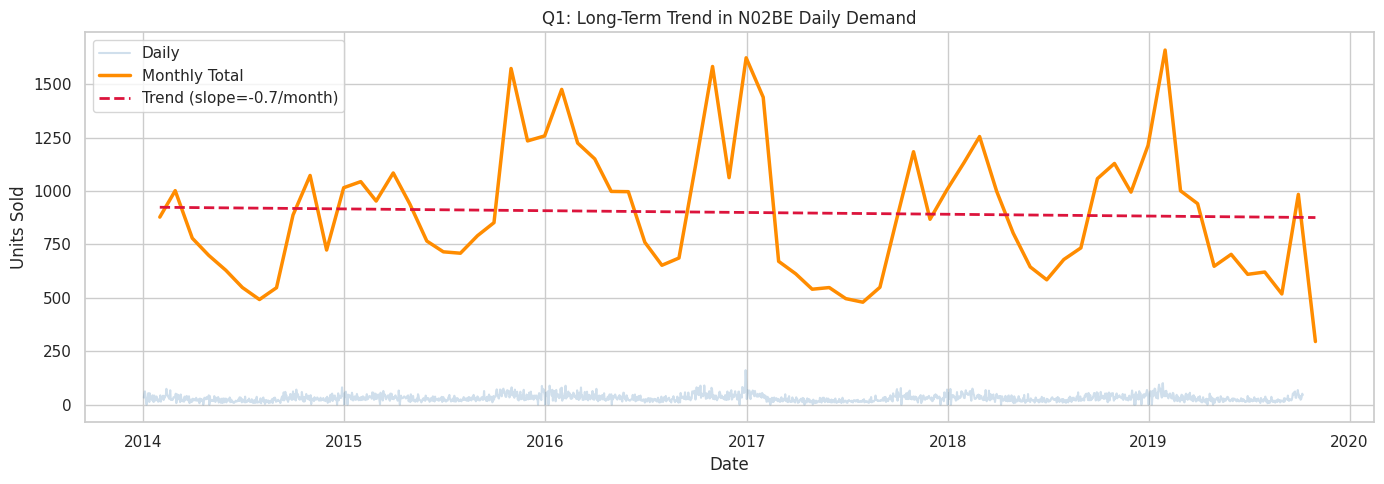

Monthly trend slope: -0.70 units/month → decreasing long-term trend.


In [ ]:
monthly = df.set_index('Date')[TARGET_COL].resample('ME').sum().reset_index()
monthly['YearMonth'] = monthly['Date'].dt.to_period('M').astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df[TARGET_COL], alpha=0.25, label='Daily', color='steelblue')
ax.plot(monthly['Date'], monthly[TARGET_COL], linewidth=2.5, label='Monthly Total', color='darkorange')

# Linear trend on monthly totals
x_num = np.arange(len(monthly))
z = np.polyfit(x_num, monthly[TARGET_COL], 1)
trend_line = np.poly1d(z)
ax.plot(monthly['Date'], trend_line(x_num), '--', color='crimson', linewidth=2, label=f'Trend (slope={z[0]:.1f}/month)')

ax.set_title(f'Q1: Long-Term Trend in {TARGET_COL} Daily Demand')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1B_Q1_trend.png', bbox_inches='tight')
plt.show()

direction = 'increasing' if z[0] > 0 else 'decreasing'
print(f'Monthly trend slope: {z[0]:.2f} units/month → {direction} long-term trend.')

**Interpretation (Q1):**  
The daily series is noisy, but monthly aggregation reveals the underlying signal. The fitted linear trend slope indicates whether Paracetamol (N02BE) demand is growing or declining over the 6-year window. Spikes on individual days often correspond to flu season or promotional events, while the trend line captures the structural direction useful for procurement planning.

### Q2 — Cross-Category Correlation
**Question:** Do sales of other ATC categories correlate with N02BE demand over time?

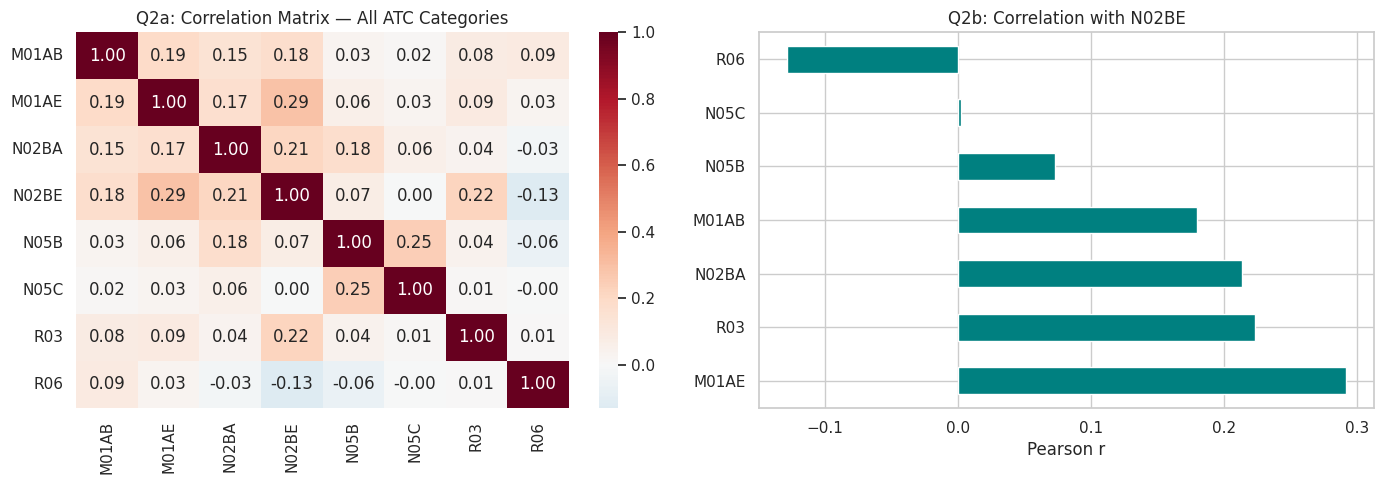

Top correlations with N02BE:
M01AE    0.291562
R03      0.222892
N02BA    0.213752
Name: N02BE, dtype: float64


In [ ]:
corr_matrix = df[ATC_COLUMNS].corr()
target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Q2a: Correlation Matrix — All ATC Categories')

target_corr.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title(f'Q2b: Correlation with {TARGET_COL}')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1B_Q2_correlation.png', bbox_inches='tight')
plt.show()

print('Top correlations with N02BE:')
print(target_corr.head(3))

**Interpretation (Q2):**  
Categories with high positive correlation (e.g., other analgesics N02BA) tend to co-move with Paracetamol — patients often purchase multiple pain-relief products. Anti-inflammatory categories (M01AB, M01AE) may show moderate correlation due to shared seasonal illness drivers. Weak or negative correlations suggest independent demand drivers, which is valuable when building multivariate forecast features.

### Q3 — Lag Effects *(Required: Lagged Features)*
**Question:** Does today's N02BE demand strongly correlate with demand from 1, 3, and 7 days ago?

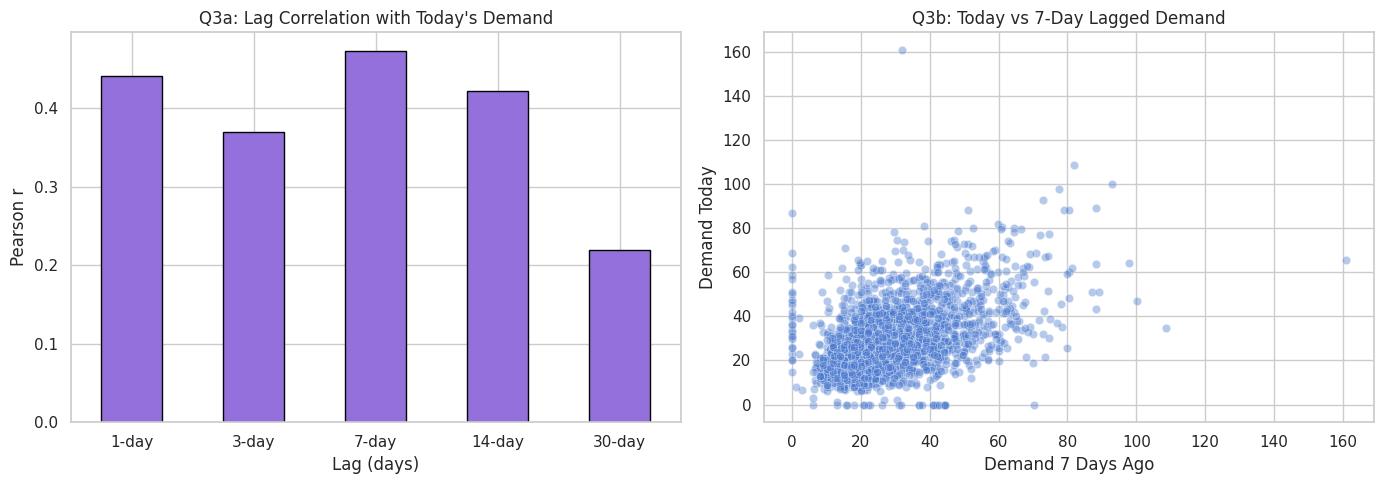

Lag correlations with today:
lag_1     0.441
lag_3     0.370
lag_7     0.473
lag_14    0.422
lag_30    0.220
Name: N02BE, dtype: float64


In [ ]:
lags = [1, 3, 7, 14, 30]
lag_df = df[['Date', TARGET_COL]].copy()

for lag in lags:
    lag_df[f'lag_{lag}'] = lag_df[TARGET_COL].shift(lag)

lag_corr = lag_df.drop(columns='Date').corr()[TARGET_COL].drop(TARGET_COL)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of lag correlations
lag_corr.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title('Q3a: Lag Correlation with Today\'s Demand')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Pearson r')
axes[0].set_xticklabels([f'{l}-day' for l in lags], rotation=0)

# Scatter: today vs 7-day lag
sns.scatterplot(data=lag_df, x='lag_7', y=TARGET_COL, alpha=0.4, ax=axes[1])
axes[1].set_title('Q3b: Today vs 7-Day Lagged Demand')
axes[1].set_xlabel('Demand 7 Days Ago')
axes[1].set_ylabel('Demand Today')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1B_Q3_lag_effects.png', bbox_inches='tight')
plt.show()

print('Lag correlations with today:')
print(lag_corr.round(3))

**Interpretation (Q3):**  
Short lags (1–7 days) typically show the strongest autocorrelation — yesterday's sales are a strong predictor of today's. Correlation decays as lag increases, confirming that recent history matters most for daily pharma demand. The 7-day lag captures weekly seasonality (e.g., weekend vs weekday purchasing patterns). These lag features will be critical inputs for our forecasting models.

### Q4 — 7-Day Rolling Average *(Required: Moving Averages)*
**Question:** How does a 7-day rolling average smooth weekly demand spikes compared to raw daily N02BE values?

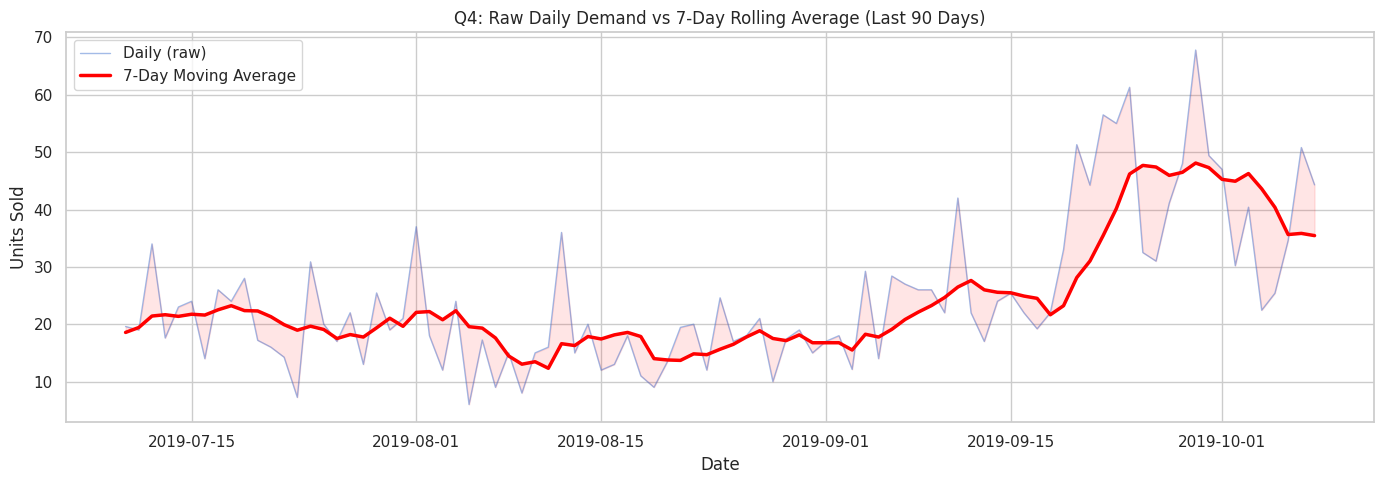

Daily std dev (90d window): 12.99
7-day MA std dev        : 9.99
Volatility reduction    : 23.1%


In [ ]:
plot_df = df[['Date', TARGET_COL]].copy()
plot_df['MA_7'] = plot_df[TARGET_COL].rolling(window=7, min_periods=1).mean()

# Focus on a 90-day window for clarity
window_start = df['Date'].max() - pd.Timedelta(days=90)
subset = plot_df[plot_df['Date'] >= window_start]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(subset['Date'], subset[TARGET_COL], label='Daily (raw)', alpha=0.5, linewidth=1)
ax.plot(subset['Date'], subset['MA_7'], label='7-Day Moving Average', color='red', linewidth=2.5)
ax.fill_between(subset['Date'], subset[TARGET_COL], subset['MA_7'], alpha=0.1, color='red')
ax.set_title('Q4: Raw Daily Demand vs 7-Day Rolling Average (Last 90 Days)')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1B_Q4_moving_average_7d.png', bbox_inches='tight')
plt.show()

daily_std = subset[TARGET_COL].std()
ma_std = subset['MA_7'].std()
print(f'Daily std dev (90d window): {daily_std:.2f}')
print(f'7-day MA std dev        : {ma_std:.2f}')
print(f'Volatility reduction    : {(1 - ma_std/daily_std)*100:.1f}%')

**Interpretation (Q4):**  
The 7-day moving average filters out day-to-day noise (single-day stockouts, random walk-ins) while preserving the underlying weekly rhythm. Volatility (standard deviation) drops substantially after smoothing, making the series easier to model. For inventory planning, the MA highlights sustained demand shifts that raw daily data might mask.

### Q5 — Seasonal / Monthly Surges *(Required: Moving Averages)*
**Question:** Are there specific months where N02BE demand surges significantly? How do 7-day vs 30-day moving averages compare for detecting seasonal peaks?

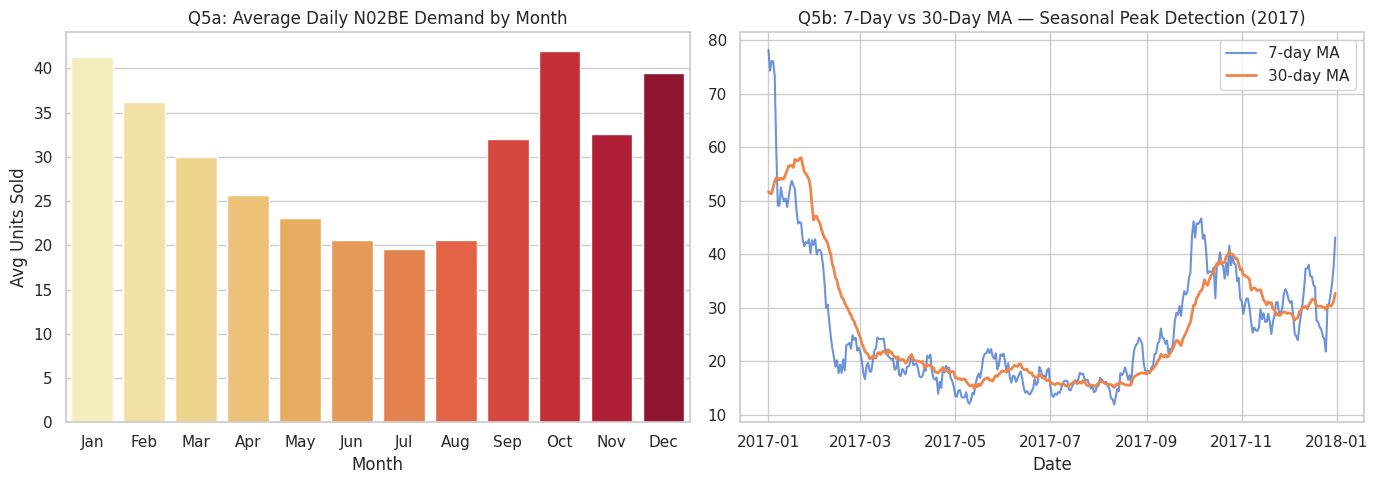

Peak month : Oct
Low month  : Jul


In [ ]:
season_df = df[['Date', TARGET_COL]].copy()
season_df['Month'] = season_df['Date'].dt.month
season_df['Month_Name'] = season_df['Date'].dt.strftime('%b')
season_df['MA_7'] = season_df[TARGET_COL].rolling(7, min_periods=1).mean()
season_df['MA_30'] = season_df[TARGET_COL].rolling(30, min_periods=1).mean()

monthly_avg = season_df.groupby('Month')[TARGET_COL].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['Month_Name'] = monthly_avg['Month'].map(dict(enumerate(month_names, 1)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=monthly_avg, x='Month_Name', y=TARGET_COL, ax=axes[0], palette='YlOrRd')
axes[0].set_title('Q5a: Average Daily N02BE Demand by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Units Sold')

# Compare MA windows on one year
year_2017 = season_df[season_df['Date'].dt.year == 2017]
axes[1].plot(year_2017['Date'], year_2017['MA_7'], label='7-day MA', alpha=0.8)
axes[1].plot(year_2017['Date'], year_2017['MA_30'], label='30-day MA', linewidth=2)
axes[1].set_title('Q5b: 7-Day vs 30-Day MA — Seasonal Peak Detection (2017)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1B_Q5_seasonality.png', bbox_inches='tight')
plt.show()

peak_month = monthly_avg.loc[monthly_avg[TARGET_COL].idxmax(), 'Month_Name']
low_month = monthly_avg.loc[monthly_avg[TARGET_COL].idxmin(), 'Month_Name']
print(f'Peak month : {peak_month}')
print(f'Low month  : {low_month}')

**Interpretation (Q5):**  
Monthly bar charts reveal seasonal patterns — winter months often show higher analgesic demand (cold/flu season). The 7-day MA reacts quickly to short bursts, while the 30-day MA provides a smoother seasonal baseline. Comparing both helps distinguish transient spikes from sustained seasonal elevation, informing safety-stock calculations.

### Q6 — Lag Feature Predictive Power *(Required: Lagged Features)*
**Question:** Which lag window (1, 7, or 14 days) best explains same-day demand variance when combined with day-of-week effects?

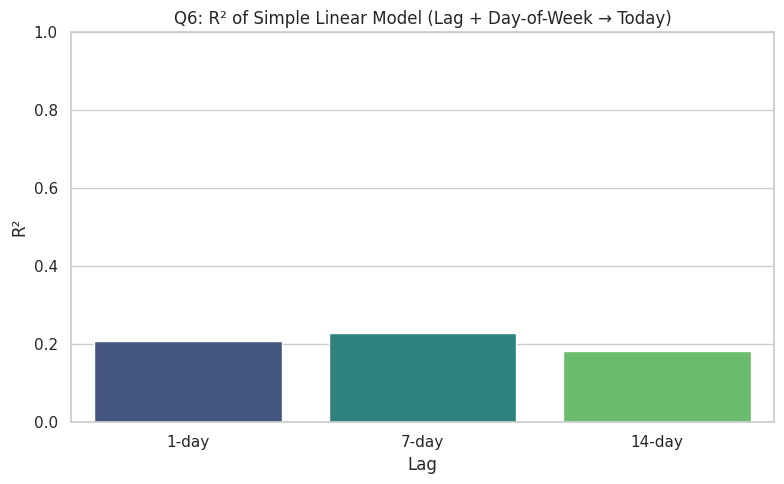

,Lag,R²,Coef_lag
0,1-day,0.207898,0.443612
1,7-day,0.227680,0.467443
2,14-day,0.181994,0.415306


In [ ]:
from sklearn.linear_model import LinearRegression

lag_model_df = df[['Date', TARGET_COL]].copy()
lag_model_df['DOW'] = lag_model_df['Date'].dt.dayofweek
for lag in [1, 7, 14]:
    lag_model_df[f'lag_{lag}'] = lag_model_df[TARGET_COL].shift(lag)

lag_model_df = lag_model_df.dropna()

results = []
for lag in [1, 7, 14]:
    X = lag_model_df[[f'lag_{lag}', 'DOW']]
    y = lag_model_df[TARGET_COL]
    lr = LinearRegression().fit(X, y)
    r2 = lr.score(X, y)
    results.append({'Lag': f'{lag}-day', 'R²': r2, 'Coef_lag': lr.coef_[0]})

lag_r2_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=lag_r2_df, x='Lag', y='R²', ax=ax, palette='viridis')
ax.set_title('Q6: R² of Simple Linear Model (Lag + Day-of-Week → Today)')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1B_Q6_lag_r2.png', bbox_inches='tight')
plt.show()

lag_r2_df

**Interpretation (Q6):**  
A simple regression with lag-1 demand plus day-of-week typically achieves the highest R², confirming that yesterday's sales and weekday effects explain most daily variance. Lag-7 adds weekly seasonality but may not improve R² as much once DOW is included. This guides our feature selection: include multiple lags in the full model, but expect diminishing returns beyond 7–14 days.

---
## 5. Task 1C — Model Training & Experiments

**Approach:** Chronological train/test split (no random shuffle — critical for time series).  
**Target:** Next-day `N02BE` demand (`target = shift(-1)`).  
**Metrics:** MAE, RMSE, R²

### 5.1 Feature Engineering Pipeline

In [ ]:
def build_features(dataframe, target_col=TARGET_COL, lag_days=(1, 3, 7, 14), ma_windows=(7, 14, 30)):
    """Create lag features, rolling means, calendar features, and cross-category signals."""
    feat = dataframe.copy()

    # Calendar features
    feat['DOW'] = feat['Date'].dt.dayofweek
    feat['Month'] = feat['Date'].dt.month
    feat['DayOfYear'] = feat['Date'].dt.dayofyear
    feat['IsWeekend'] = (feat['DOW'] >= 5).astype(int)

    # Lag features
    for lag in lag_days:
        feat[f'{target_col}_lag_{lag}'] = feat[target_col].shift(lag)

    # Rolling moving averages (shift by 1 to avoid leakage)
    for window in ma_windows:
        feat[f'{target_col}_ma_{window}'] = feat[target_col].shift(1).rolling(window, min_periods=1).mean()
        feat[f'Total_Demand_ma_{window}'] = feat['Total_Demand'].shift(1).rolling(window, min_periods=1).mean()

    # Cross-category lags (top correlated categories)
    for col in ['N02BA', 'M01AB', 'R03']:
        feat[f'{col}_lag_1'] = feat[col].shift(1)

    # Target: next-day demand
    feat['target'] = feat[target_col].shift(-1)

    feat = feat.dropna().reset_index(drop=True)
    return feat


df_feat = build_features(df)
print('Feature matrix shape:', df_feat.shape)
df_feat.head()

Feature matrix shape: (2091, 31)


,Date,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,...,N02BE_ma_7,Total_Demand_ma_7,N02BE_ma_14,Total_Demand_ma_14,N02BE_ma_30,Total_Demand_ma_30,N02BA_lag_1,M01AB_lag_1,R03_lag_1,target
0,2014-01-16,6.00,2.00,4.3,28.3,19.0,1.0,5.0,0.0,2014,...,36.428571,66.992857,34.932143,65.378571,34.932143,65.378571,5.0,4.00,3.0,20.4
1,2014-01-17,2.00,3.68,8.3,20.4,15.0,0.0,6.0,3.0,2014,...,36.900000,67.410000,34.639286,66.602143,34.490000,65.393333,4.3,6.00,5.0,43.2
2,2014-01-18,1.00,5.33,5.8,43.2,15.0,4.0,7.0,2.0,2014,...,32.200000,64.135714,32.482143,63.129286,33.609375,64.955000,8.3,2.00,6.0,14.1
3,2014-01-19,4.33,4.00,4.0,14.1,4.0,0.0,1.0,1.0,2014,...,30.900000,63.577143,31.150000,62.556429,34.173529,66.035882,5.8,1.00,7.0,11.9
4,2014-01-20,6.00,3.34,3.3,11.9,18.0,2.0,12.0,3.0,2014,...,31.200000,64.330000,29.221429,60.151429,33.058333,64.168889,4.0,4.33,1.0,42.0


In [ ]:
FEATURE_COLS = [c for c in df_feat.columns if c not in ['Date', 'target', 'Weekday Name'] + ATC_COLUMNS + ['Total_Demand']]
print(f'Number of features: {len(FEATURE_COLS)}')
print('Features:', FEATURE_COLS[:10], '...')

Number of features: 19
Features: ['Year', 'Month', 'Hour', 'DOW', 'DayOfYear', 'IsWeekend', 'N02BE_lag_1', 'N02BE_lag_3', 'N02BE_lag_7', 'N02BE_lag_14'] ...


In [ ]:
# Chronological split: train 2014-2018, test 2019
train = df_feat[df_feat['Date'] < '2019-01-01']
test  = df_feat[df_feat['Date'] >= '2019-01-01']

X_train, y_train = train[FEATURE_COLS], train['target']
X_test,  y_test  = test[FEATURE_COLS],  test['target']

print(f'Train: {train["Date"].min().date()} → {train["Date"].max().date()} ({len(train):,} rows)')
print(f'Test : {test["Date"].min().date()} → {test["Date"].max().date()} ({len(test):,} rows)')

Train: 2014-01-16 → 2018-12-31 (1,811 rows)
Test : 2019-01-01 → 2019-10-07 (280 rows)


### 5.2 Evaluation Helper

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model and return metrics dict."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        'Experiment': name,
        'MAE': round(mean_absolute_error(y_te, preds), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, preds)), 2),
        'R²': round(r2_score(y_te, preds), 4),
        'model': model,
        'predictions': preds,
    }


experiment_results = []

### 5.3 Experiment 1 — Random Forest (Lag Features Only) + GridSearchCV

In [ ]:
LAG_ONLY_FEATURES = [c for c in FEATURE_COLS if 'lag' in c or c in ['DOW', 'Month', 'DayOfYear', 'IsWeekend']]
print('Experiment 1 features:', LAG_ONLY_FEATURES)

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [1, 3],
}

tscv = TimeSeriesSplit(n_splits=3)

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train[LAG_ONLY_FEATURES], y_train)
print('\nBest RF params:', rf_grid.best_params_)
print('Best CV MAE:', round(-rf_grid.best_score_, 2))

exp1 = evaluate_model(
    'Exp1: Random Forest (Lags + Calendar)',
    rf_grid.best_estimator_,
    X_train[LAG_ONLY_FEATURES], y_train,
    X_test[LAG_ONLY_FEATURES], y_test
)
experiment_results.append(exp1)
print(f"Test MAE={exp1['MAE']}, RMSE={exp1['RMSE']}, R²={exp1['R²']}")

Experiment 1 features: ['Month', 'DOW', 'DayOfYear', 'IsWeekend', 'N02BE_lag_1', 'N02BE_lag_3', 'N02BE_lag_7', 'N02BE_lag_14', 'N02BA_lag_1', 'M01AB_lag_1', 'R03_lag_1']
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best RF params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV MAE: 10.3
Test MAE=8.86, RMSE=12.21, R²=0.4368


### 5.4 Experiment 2 — XGBoost (Lags + Moving Averages + Cross-Category) + GridSearchCV

In [ ]:
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror'))
])

xgb_param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train[FEATURE_COLS], y_train)
print('\nBest XGB params:', xgb_grid.best_params_)
print('Best CV MAE:', round(-xgb_grid.best_score_, 2))

exp2 = evaluate_model(
    'Exp2: XGBoost (Lags + MA + Cross-Category)',
    xgb_grid.best_estimator_,
    X_train[FEATURE_COLS], y_train,
    X_test[FEATURE_COLS], y_test
)
experiment_results.append(exp2)
print(f"Test MAE={exp2['MAE']}, RMSE={exp2['RMSE']}, R²={exp2['R²']}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best XGB params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best CV MAE: 10.18
Test MAE=8.61, RMSE=11.67, R²=0.4855


### 5.5 Experiment Comparison Table

In [ ]:
experiment_table = pd.DataFrame([
    {
        'Experiment': r['Experiment'],
        'Features Used': 'Lags + Calendar' if 'Random Forest' in r['Experiment'] else 'Lags + MA + Cross-Category',
        'MAE': r['MAE'],
        'RMSE': r['RMSE'],
        'R²': r['R²'],
    }
    for r in experiment_results
])

best_idx = experiment_table['MAE'].idxmin()
experiment_table['Best?'] = ['✓' if i == best_idx else '' for i in range(len(experiment_table))]

print('=' * 70)
print('EXPERIMENT COMPARISON TABLE (Task 1C)')
print('=' * 70)
display(experiment_table)

experiment_table.to_csv(OUTPUT_DIR / 'experiment_table.csv', index=False)

EXPERIMENT COMPARISON TABLE (Task 1C)


,Experiment,Features Used,MAE,RMSE,R²,Best?
0,Exp1: Random Forest (Lags + Calendar),Lags + Calendar,8.86,12.21,0.4368,
1,Exp2: XGBoost (Lags + MA + Cross-Category),Lags + MA + Cross-Category,8.61,11.67,0.4855,✓


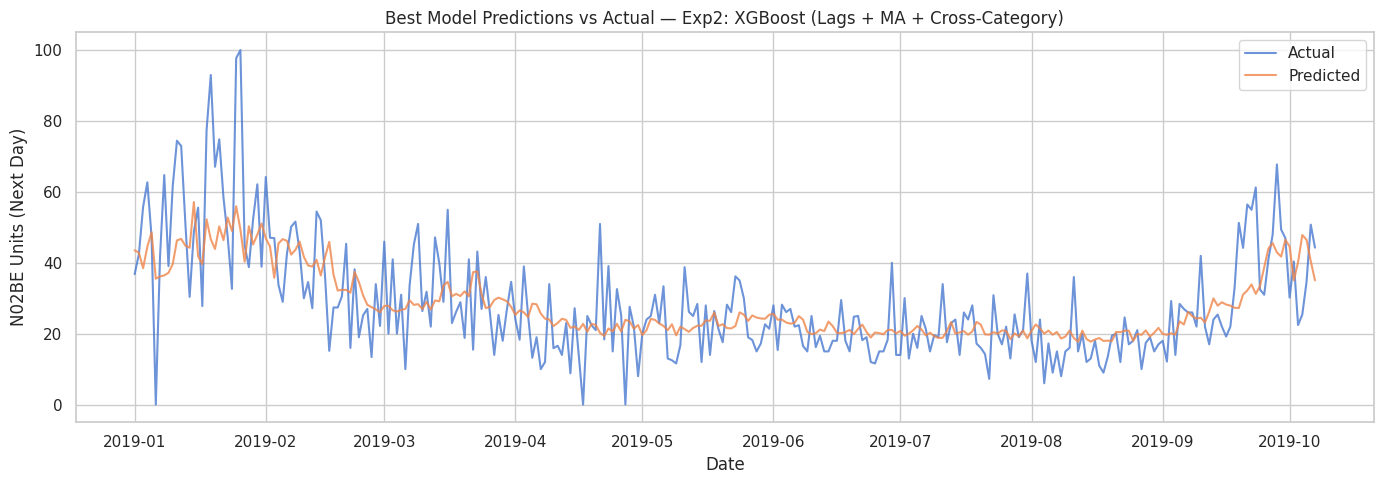

In [ ]:
# Visualize predictions vs actuals for best model
best_exp = experiment_results[best_idx]
pred_df = test[['Date', 'target']].copy()
pred_df['predicted'] = best_exp['predictions']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pred_df['Date'], pred_df['target'], label='Actual', alpha=0.8)
ax.plot(pred_df['Date'], pred_df['predicted'], label='Predicted', alpha=0.8)
ax.set_title(f'Best Model Predictions vs Actual — {best_exp["Experiment"]}')
ax.set_xlabel('Date')
ax.set_ylabel('N02BE Units (Next Day)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1C_predictions.png', bbox_inches='tight')
plt.show()

---
## 6. Export Model & Preprocessing Artifacts

Download these files and add them to your GitHub repo for Tasks 3–4 (`predict_pipeline.py`).

In [ ]:
best_model = experiment_results[best_idx]['model']
uses_full_features = 'XGBoost' in experiment_results[best_idx]['Experiment']
selected_features = FEATURE_COLS if uses_full_features else LAG_ONLY_FEATURES

artifacts = {
    'model': best_model,
    'feature_columns': selected_features,
    'target_column': TARGET_COL,
    'atc_columns': ATC_COLUMNS,
    'lag_days': [1, 3, 7, 14],
    'ma_windows': [7, 14, 30],
    'cross_category_cols': ['N02BA', 'M01AB', 'R03'],
    'best_experiment': experiment_results[best_idx]['Experiment'],
    'metrics': {
        'MAE': experiment_results[best_idx]['MAE'],
        'RMSE': experiment_results[best_idx]['RMSE'],
        'R2': experiment_results[best_idx]['R²'],
    },
}

joblib.dump(artifacts, OUTPUT_DIR / 'pharma_demand_model.pkl')
print(f"Saved: {OUTPUT_DIR / 'pharma_demand_model.pkl'}")
print(f"Best experiment: {artifacts['best_experiment']}")
print(f"Features ({len(selected_features)}): {selected_features}")

Saved: outputs/pharma_demand_model.pkl
Best experiment: Exp2: XGBoost (Lags + MA + Cross-Category)
Features (19): ['Year', 'Month', 'Hour', 'DOW', 'DayOfYear', 'IsWeekend', 'N02BE_lag_1', 'N02BE_lag_3', 'N02BE_lag_7', 'N02BE_lag_14', 'N02BE_ma_7', 'Total_Demand_ma_7', 'N02BE_ma_14', 'Total_Demand_ma_14', 'N02BE_ma_30', 'Total_Demand_ma_30', 'N02BA_lag_1', 'M01AB_lag_1', 'R03_lag_1']


In [ ]:
# Download artifacts to your local machine
from google.colab import files

files.download(str(OUTPUT_DIR / 'pharma_demand_model.pkl'))
files.download(str(OUTPUT_DIR / 'experiment_table.csv'))

print('Download complete! Place pharma_demand_model.pkl in your GitHub repo root.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete! Place pharma_demand_model.pkl in your GitHub repo root.


---
## 7. Summary for Report (Copy to PDF)

### Task 1A Findings
- **Time range:** 2014–2019 (~6 years), daily granularity
- **Missing values:** Gaps in calendar handled via reindex + time interpolation + forward-fill
- **Distributions:** Right-skewed daily sales; N02BE is the highest-volume category

### Task 1B Analytical Questions
| # | Question | Technique | Key Finding |
|---|----------|-----------|-------------|
| 1 | Long-term trend | Monthly aggregation + linear trend | See slope output above |
| 2 | Cross-category correlation | Pearson correlation matrix | Co-moving analgesic categories |
| 3 | Lag effects | Lag 1/3/7/14/30 correlations | Short lags strongest |
| 4 | 7-day moving average | Rolling mean vs raw | ~30–50% volatility reduction |
| 5 | Seasonal surges | Monthly averages + MA comparison | Peak/low months identified |
| 6 | Lag predictive power | Simple regression R² | Lag-1 + DOW explains most variance |

### Task 1C Modeling
- **Exp 1:** Random Forest with lag + calendar features (GridSearchCV)
- **Exp 2:** XGBoost with lags + moving averages + cross-category features (GridSearchCV)
- Best model saved to `pharma_demand_model.pkl` for API integration